# 5. Loading Preprocessed Data

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import requests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc,
)

random_state = 42


In [35]:
df = pd.read_csv("./data/clean_data_v1.csv")
df = df.drop(columns=["Unnamed: 0"])
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


# 6. Class Distribution

In [36]:
class_counts = df["Exited"].value_counts()
class_percent = df["Exited"].value_counts(normalize=True) * 100
print(class_counts)
print(class_percent.round(2))


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


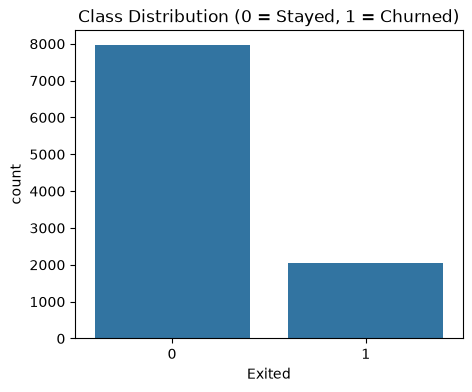

In [37]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Exited", data=df)
plt.title("Class Distribution (0 = Stayed, 1 = Churned)")
plt.savefig("artifacts/class_distribution.png", dpi=150)
plt.show()


Dataset is imbalanced: ~80% stayed, ~20% churned. Accuracy alone won't tell us much, so we look at precision/recall/F1 and the ROC/PR curves too.

# 7. Train / Validation / Test Split

In [38]:
x = df.drop(columns=["Exited"])
y = df["Exited"]

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.4, stratify=y, random_state=random_state
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=random_state
)

print("train:", x_train.shape, "churn rate:", round(y_train.mean(), 3))
print("val:  ", x_val.shape, "churn rate:", round(y_val.mean(), 3))
print("test: ", x_test.shape, "churn rate:", round(y_test.mean(), 3))


train: (6000, 10) churn rate: 0.204
val:   (2000, 10) churn rate: 0.204
test:  (2000, 10) churn rate: 0.204


# 8. Feature Scaling

In [39]:
feature_names = x_train.columns.tolist()

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)


# 9. Train the Models

In [40]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state)
log_reg.fit(x_train_scaled, y_train)

rand_forest = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                      random_state=random_state, n_jobs=-1)
rand_forest.fit(x_train_scaled, y_train)

svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=random_state)
svm_model.fit(x_train_scaled, y_train)

print("all models trained")


c:\Users\o\Desktop\New folder (2)\Customer_Retention_Predictor\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


all models trained


# 10. Validation Prediction Probabilities

In [41]:
log_reg_val_probs = log_reg.predict_proba(x_val_scaled)[:, 1]
rand_forest_val_probs = rand_forest.predict_proba(x_val_scaled)[:, 1]
svm_val_probs = svm_model.predict_proba(x_val_scaled)[:, 1]


# 11. Threshold Analysis

In [42]:
def evaluate_thresholds(y_true, probs):
    rows = []
    for t in np.arange(0.05, 0.96, 0.05):
        preds = (probs >= t).astype(int)
        rows.append({
            "threshold": round(t, 2),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
        })
    return pd.DataFrame(rows)

log_reg_thresholds = evaluate_thresholds(y_val, log_reg_val_probs)
rand_forest_thresholds = evaluate_thresholds(y_val, rand_forest_val_probs)
svm_thresholds = evaluate_thresholds(y_val, svm_val_probs)

rand_forest_thresholds.round(3)


,threshold,precision,recall,f1
0,0.05,0.204,1.000,0.339
1,0.10,0.219,0.998,0.359
2,0.15,0.242,0.993,0.390
3,0.20,0.264,0.978,0.416
4,0.25,0.290,0.968,0.446
5,0.30,0.330,0.929,0.487
6,0.35,0.370,0.892,0.523
7,0.40,0.412,0.848,0.554
8,0.45,0.464,0.797,0.586
9,0.50,0.526,0.738,0.614


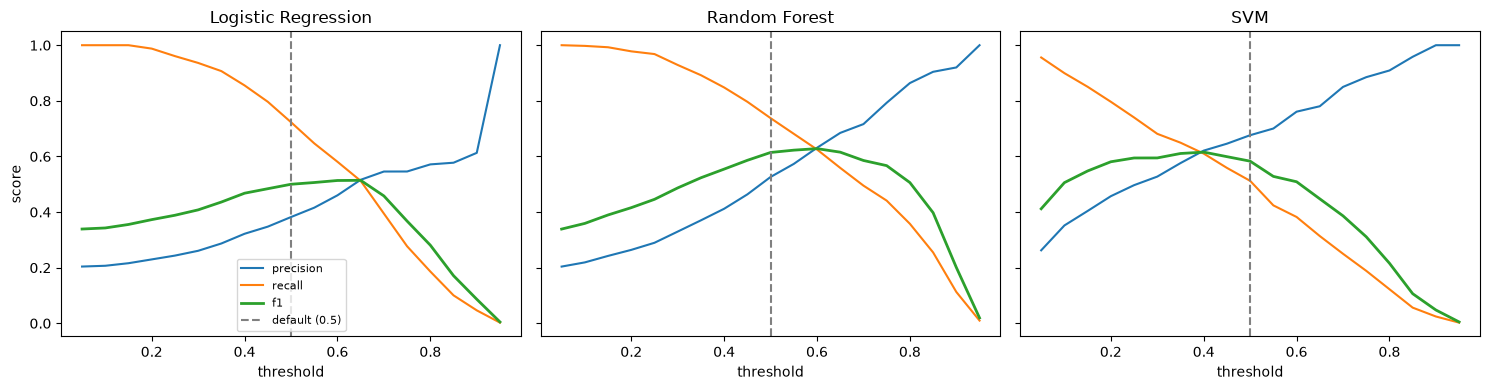

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name, table in zip(
    axes,
    ["Logistic Regression", "Random Forest", "SVM"],
    [log_reg_thresholds, rand_forest_thresholds, svm_thresholds],
):
    ax.plot(table["threshold"], table["precision"], label="precision")
    ax.plot(table["threshold"], table["recall"], label="recall")
    ax.plot(table["threshold"], table["f1"], label="f1", linewidth=2)
    ax.axvline(0.5, color="gray", linestyle="--", label="default (0.5)")
    ax.set_title(name)
    ax.set_xlabel("threshold")

axes[0].set_ylabel("score")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("artifacts/threshold_curves.png", dpi=150)
plt.show()


In [44]:
log_reg_best_threshold = log_reg_thresholds.loc[log_reg_thresholds["f1"].idxmax(), "threshold"]
rand_forest_best_threshold = rand_forest_thresholds.loc[rand_forest_thresholds["f1"].idxmax(), "threshold"]
svm_best_threshold = svm_thresholds.loc[svm_thresholds["f1"].idxmax(), "threshold"]

print("Logistic Regression optimal threshold:", log_reg_best_threshold)
print("Random Forest optimal threshold:", rand_forest_best_threshold)
print("SVM optimal threshold:", svm_best_threshold)


Logistic Regression optimal threshold: 0.65
Random Forest optimal threshold: 0.6
SVM optimal threshold: 0.4


# 12. Default vs Optimal Threshold (Validation)

In [45]:
def compare_thresholds(y_true, probs, best_threshold):
    default_preds = (probs >= 0.5).astype(int)
    best_preds = (probs >= best_threshold).astype(int)
    return {
        "default_f1": f1_score(y_true, default_preds, zero_division=0),
        "optimal_threshold": best_threshold,
        "optimal_f1": f1_score(y_true, best_preds, zero_division=0),
    }

comparison_table = pd.DataFrame([
    {"model": "Logistic Regression", **compare_thresholds(y_val, log_reg_val_probs, log_reg_best_threshold)},
    {"model": "Random Forest", **compare_thresholds(y_val, rand_forest_val_probs, rand_forest_best_threshold)},
    {"model": "SVM", **compare_thresholds(y_val, svm_val_probs, svm_best_threshold)},
]).round(3)

comparison_table


,model,default_f1,optimal_threshold,optimal_f1
0,Logistic Regression,0.500,0.65,0.514
1,Random Forest,0.614,0.60,0.628
2,SVM,0.583,0.40,0.616


# 13. Test Set Evaluation

In [46]:
log_reg_test_probs = log_reg.predict_proba(x_test_scaled)[:, 1]
rand_forest_test_probs = rand_forest.predict_proba(x_test_scaled)[:, 1]
svm_test_probs = svm_model.predict_proba(x_test_scaled)[:, 1]


In [47]:
models_info = [
    ("Logistic Regression", log_reg_test_probs, log_reg_best_threshold),
    ("Random Forest", rand_forest_test_probs, rand_forest_best_threshold),
    ("SVM", svm_test_probs, svm_best_threshold),
]

for name, probs, best_threshold in models_info:
    print("=" * 60)
    print(name)
    print("=" * 60)
    preds_default = (probs >= 0.5).astype(int)
    preds_optimal = (probs >= best_threshold).astype(int)
    print("-- default threshold 0.5 --")
    print(classification_report(y_test, preds_default, target_names=["Stayed", "Churned"], zero_division=0))
    print(f"-- optimal threshold {best_threshold} --")
    print(classification_report(y_test, preds_optimal, target_names=["Stayed", "Churned"], zero_division=0))


Logistic Regression
-- default threshold 0.5 --
              precision    recall  f1-score   support

      Stayed       0.90      0.70      0.79      1593
     Churned       0.37      0.71      0.49       407

    accuracy                           0.70      2000
   macro avg       0.64      0.70      0.64      2000
weighted avg       0.79      0.70      0.73      2000

-- optimal threshold 0.65 --
              precision    recall  f1-score   support

      Stayed       0.87      0.88      0.87      1593
     Churned       0.50      0.47      0.49       407

    accuracy                           0.80      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.79      0.80      0.79      2000

Random Forest
-- default threshold 0.5 --
              precision    recall  f1-score   support

      Stayed       0.92      0.83      0.87      1593
     Churned       0.52      0.71      0.60       407

    accuracy                           0.81      2000
   macro 

### Confusion Matrices (test set, optimal threshold)

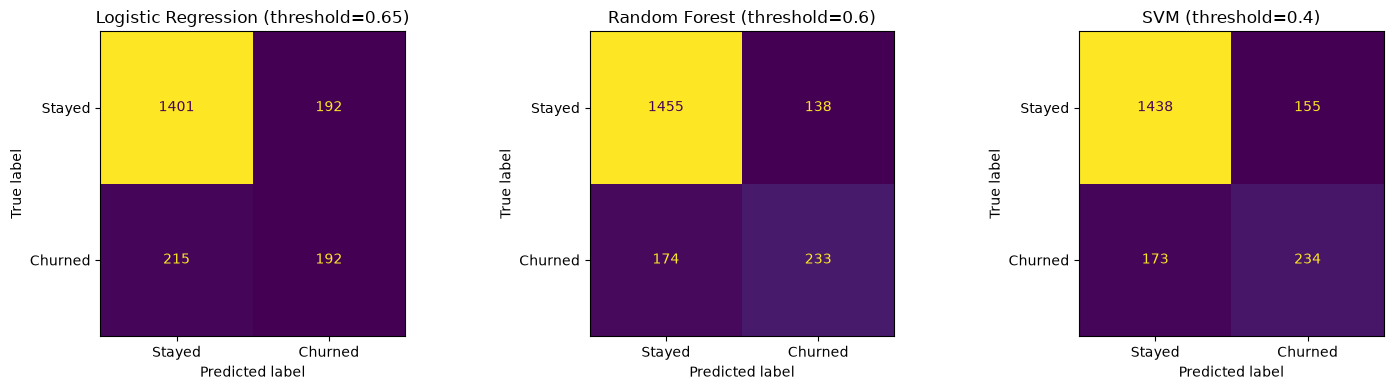

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, probs, best_threshold) in zip(axes, models_info):
    preds = (probs >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} (threshold={best_threshold})")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrices.png", dpi=150)
plt.show()


### Precision-Recall Curve (test set)

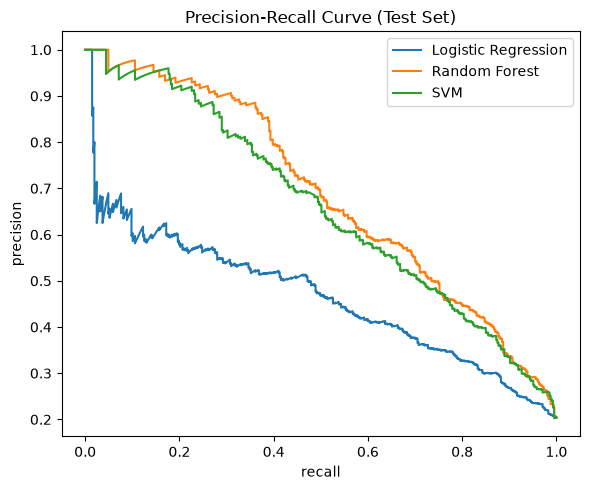

In [49]:
plt.figure(figsize=(6, 5))
for name, probs, _ in models_info:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Precision-Recall Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/pr_curve.png", dpi=150)
plt.show()


### ROC Curve (test set)

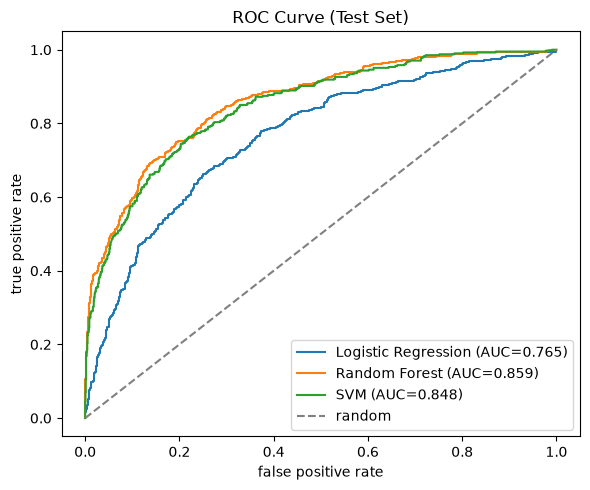

In [50]:
plt.figure(figsize=(6, 5))
for name, probs, _ in models_info:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="random")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/roc_curve.png", dpi=150)
plt.show()


# 14. Pick the Best Model and Save It

In [51]:
results_table = []
for name, probs, best_threshold in models_info:
    preds = (probs >= best_threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_test, probs)
    results_table.append({
        "model": name,
        "optimal_threshold": best_threshold,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": auc(fpr, tpr),
    })

results_table = pd.DataFrame(results_table).round(3).sort_values("f1", ascending=False)
results_table


,model,optimal_threshold,precision,recall,f1,roc_auc
1,Random Forest,0.60,0.628,0.572,0.599,0.859
2,SVM,0.40,0.602,0.575,0.588,0.848
0,Logistic Regression,0.65,0.500,0.472,0.485,0.765


In [52]:
best_model_name = results_table.iloc[0]["model"]

model_lookup = {
    "Logistic Regression": (log_reg, log_reg_best_threshold),
    "Random Forest": (rand_forest, rand_forest_best_threshold),
    "SVM": (svm_model, svm_best_threshold),
}
best_model, best_threshold = model_lookup[best_model_name]

print("best model:", best_model_name, "threshold:", best_threshold)

os.makedirs("models", exist_ok=True)
joblib.dump({
    "model": best_model,
    "model_name": best_model_name,
    "scaler": scaler,
    "feature_names": feature_names,
    "threshold": best_threshold,
}, "models/churn_model_bundle.joblib")

results_table.to_csv("models/model_comparison.csv", index=False)
print("saved models/churn_model_bundle.joblib and models/model_comparison.csv")


best model: Random Forest threshold: 0.6
saved models/churn_model_bundle.joblib and models/model_comparison.csv


# 15. LLM Integration (LM Studio) — Zero-shot, Few-shot, Reasoning



In [66]:
lm_studio_url = "http://localhost:3346/v1/chat/completions"
lm_studio_model = "lfm2.5-1.2b-instruct"

def call_lm_studio(messages):
    response = requests.post(lm_studio_url, json={
        "model": lm_studio_model,
        "messages": messages,
        "temperature": 0.3,
        "max_tokens": 400,
    })
    return response.json()["choices"][0]["message"]["content"]


In [67]:
# grab one real at-risk customer from the test set to ground the prompts
x_test_reset = x_test.reset_index(drop=True)
at_risk_index = x_test_reset.index[best_model.predict_proba(scaler.transform(x_test_reset))[:, 1] >= best_threshold][0]

customer_profile = x_test_reset.iloc[at_risk_index].to_dict()
customer_profile["predicted_churn_probability"] = round(
    float(best_model.predict_proba(scaler.transform(x_test_reset))[at_risk_index, 1]), 3
)
customer_profile


{'CreditScore': 770.0,
 'Geography': 0.0,
 'Gender': 0.0,
 'Age': 70.0,
 'Tenure': 9.0,
 'Balance': 110738.89,
 'NumOfProducts': 1.0,
 'HasCrCard': 1.0,
 'IsActiveMember': 0.0,
 'EstimatedSalary': 22666.77,
 'predicted_churn_probability': 0.788}

### 15.1 Zero-shot

In [68]:
zero_shot_messages = [
    {"role": "system", "content": "You are a customer retention analyst for a bank."},
    {"role": "user", "content": f"Customer profile: {customer_profile}\n\nIn 3-4 sentences, assess churn risk and suggest one retention action."},
]
print(call_lm_studio(zero_shot_messages))


KeyError: 'choices'

### 15.2 Few-shot

In [69]:
few_shot_messages = [
    {"role": "system", "content": "You are a customer retention analyst for a bank. Follow the format in the examples."},
    {"role": "user", "content": (
        "Example 1:\nProfile: {'Age': 58, 'Balance': 0, 'NumOfProducts': 1, 'IsActiveMember': 0, 'predicted_churn_probability': 0.81}\n"
        "Risk: HIGH\nAction: Call the customer, waive fees, offer a relationship-manager check-in.\n\n"
        "Example 2:\nProfile: {'Age': 30, 'Balance': 60000, 'NumOfProducts': 2, 'IsActiveMember': 1, 'predicted_churn_probability': 0.12}\n"
        "Risk: LOW\nAction: No immediate action; standard loyalty email.\n\n"
        f"Now do the same for:\nProfile: {customer_profile}\nRisk:\nAction:"
    )},
]
print(call_lm_studio(few_shot_messages))


KeyError: 'choices'

### 15.3 Reasoning

In [70]:
reasoning_messages = [
    {"role": "system", "content": "You are a customer retention analyst for a bank. Think step by step."},
    {"role": "user", "content": (
        f"Customer profile: {customer_profile}\n\n"
        "Step 1: list factors that increase or decrease churn risk.\n"
        "Step 2: weigh the factors against each other.\n"
        "Step 3: give a final risk level (LOW/MEDIUM/HIGH) and one concrete retention action."
    )},
]
print(call_lm_studio(reasoning_messages))


KeyError: 'choices'